In [4]:
!pip install tensorflow

  Using cached tensorflow-2.20.0-cp312-cp312-win_amd64.whl.metadata (4.6 kB)
  Using cached astunparse-1.6.3-py2.py3-none-any.whl.metadata (4.4 kB)
  Using cached grpcio-1.78.0-cp312-cp312-win_amd64.whl.metadata (3.9 kB)
  Using cached tensorboard-2.20.0-py3-none-any.whl.metadata (1.8 kB)
  Using cached keras-3.13.2-py3-none-any.whl.metadata (6.3 kB)
  Using cached h5py-3.15.1-cp312-cp312-win_amd64.whl.metadata (3.1 kB)
  Using cached rich-14.3.3-py3-none-any.whl.metadata (18 kB)
Using cached tensorflow-2.20.0-cp312-cp312-win_amd64.whl (331.9 MB)
   ---------------------------------------- 0.0/4.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/4.8 MB ? eta -:--:--
   ------ --------------------------------- 0.8/4.8 MB 3.0 MB/s eta 0:00:02
   -------- ------------------------------- 1.0/4.8 MB 2.5 MB/s eta 0:00:02
   ---------- ----------------------------- 1.3/4.8 MB 2.5 MB/s eta 0:00:02
   --------------- ------------------------ 1.8/4.8 MB 2.2 MB/s eta 0:00:02
   --

In [13]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

In [22]:
IMG_SIZE = 224
BATCH_SIZE = 32
DATASET_PATH = "../Dataset"

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2,
    rotation_range=30,
    zoom_range=0.2,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    brightness_range=[0.8,1.2]
)

val_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2
)

In [23]:
train_data = train_datagen.flow_from_directory(
    DATASET_PATH,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="training",
    shuffle=True
)

val_data = val_datagen.flow_from_directory(
    DATASET_PATH,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="validation",
    shuffle=False
)

print(train_data.class_indices)

Found 3255 images belonging to 8 classes.
Found 811 images belonging to 8 classes.
{'Abnormal': 0, 'Anthracnose': 1, 'Black_Spot': 2, 'Dry_Leaf': 3, 'Healthy': 4, 'Leaf_Blight': 5, 'Leaf_Spot': 6, 'Powdery_Mildew': 7}


In [24]:
base_model = EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

model = models.Sequential([
    
    base_model,
    
    layers.GlobalAveragePooling2D(),
    
    layers.BatchNormalization(),
    
    layers.Dense(
        256,
        activation="relu",
        kernel_regularizer=regularizers.l2(0.01)
    ),
    
    layers.Dropout(0.5),
    
    layers.Dense(8, activation="softmax")
])

In [25]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [33]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


In [34]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.3,
    patience=3
)

checkpoint = ModelCheckpoint(
    "best_leaf_model.h5",
    save_best_only=True
)

In [35]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=30,
    callbacks=[early_stop, reduce_lr, checkpoint]
)

Epoch 1/30
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8810 - loss: 0.7584

102/102 ━━━━━━━━━━━━━━━━━━━━ 200s 2s/step - accuracy: 0.8888 - loss: 0.7367 - val_accuracy: 0.8903 - val_loss: 0.7680 - learning_rate: 1.0000e-04
Epoch 2/30
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8816 - loss: 0.6863

102/102 ━━━━━━━━━━━━━━━━━━━━ 178s 2s/step - accuracy: 0.8851 - loss: 0.6691 - val_accuracy: 0.8878 - val_loss: 0.7220 - learning_rate: 1.0000e-04
Epoch 3/30
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8953 - loss: 0.6177

102/102 ━━━━━━━━━━━━━━━━━━━━ 176s 2s/step - accuracy: 0.8940 - loss: 0.6048 - val_accuracy: 0.8927 - val_loss: 0.6460 - learning_rate: 1.0000e-04
Epoch 4/30
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8806 - loss: 0.5767

102/102 ━━━━━━━━━━━━━━━━━━━━ 195s 2s/step - accuracy: 0.8900 - loss: 0.5588 - val_accuracy: 0.8964 - val_loss: 0.6003 - learning_rate: 1.0000e-04
Epoch 5/30
102/102 ━━━━━━━━━━━━━━━━━━━━ 205s 2s/step - accuracy: 0.8906 - loss: 0.5147 - val_accuracy: 0.8964 - val_loss: 0.6138 - learning_rate: 1.0000e-04
Epoch 6/30
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9004 - loss: 0.4735

102/102 ━━━━━━━━━━━━━━━━━━━━ 197s 2s/step - accuracy: 0.8922 - loss: 0.4706 - val_accuracy: 0.8977 - val_loss: 0.5263 - learning_rate: 1.0000e-04
Epoch 7/30
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8966 - loss: 0.4322

102/102 ━━━━━━━━━━━━━━━━━━━━ 173s 2s/step - accuracy: 0.8885 - loss: 0.4334 - val_accuracy: 0.9001 - val_loss: 0.4658 - learning_rate: 1.0000e-04
Epoch 8/30
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8920 - loss: 0.4089

102/102 ━━━━━━━━━━━━━━━━━━━━ 190s 2s/step - accuracy: 0.8931 - loss: 0.4031 - val_accuracy: 0.8977 - val_loss: 0.4516 - learning_rate: 1.0000e-04
Epoch 9/30
102/102 ━━━━━━━━━━━━━━━━━━━━ 179s 2s/step - accuracy: 0.8906 - loss: 0.3741 - val_accuracy: 0.8915 - val_loss: 0.5146 - learning_rate: 1.0000e-04
Epoch 10/30
102/102 ━━━━━━━━━━━━━━━━━━━━ 170s 2s/step - accuracy: 0.8955 - loss: 0.3497 - val_accuracy: 0.8927 - val_loss: 0.5235 - learning_rate: 1.0000e-04
Epoch 11/30
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8937 - loss: 0.3329

102/102 ━━━━━━━━━━━━━━━━━━━━ 171s 2s/step - accuracy: 0.8943 - loss: 0.3281 - val_accuracy: 0.8989 - val_loss: 0.3958 - learning_rate: 1.0000e-04
Epoch 12/30
102/102 ━━━━━━━━━━━━━━━━━━━━ 170s 2s/step - accuracy: 0.8866 - loss: 0.3106 - val_accuracy: 0.8977 - val_loss: 0.4001 - learning_rate: 1.0000e-04
Epoch 13/30
102/102 ━━━━━━━━━━━━━━━━━━━━ 2476s 24s/step - accuracy: 0.8879 - loss: 0.2932 - val_accuracy: 0.8989 - val_loss: 0.4053 - learning_rate: 1.0000e-04
Epoch 14/30
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8980 - loss: 0.2832

102/102 ━━━━━━━━━━━━━━━━━━━━ 189s 2s/step - accuracy: 0.8949 - loss: 0.2802 - val_accuracy: 0.8989 - val_loss: 0.3835 - learning_rate: 1.0000e-04
Epoch 15/30
102/102 ━━━━━━━━━━━━━━━━━━━━ 193s 2s/step - accuracy: 0.8869 - loss: 0.2664 - val_accuracy: 0.8977 - val_loss: 0.4515 - learning_rate: 1.0000e-04
Epoch 16/30
102/102 ━━━━━━━━━━━━━━━━━━━━ 215s 2s/step - accuracy: 0.8925 - loss: 0.2535 - val_accuracy: 0.8989 - val_loss: 0.4015 - learning_rate: 1.0000e-04
Epoch 17/30
102/102 ━━━━━━━━━━━━━━━━━━━━ 203s 2s/step - accuracy: 0.8916 - loss: 0.2450 - val_accuracy: 0.8964 - val_loss: 0.4194 - learning_rate: 1.0000e-04
Epoch 18/30
102/102 ━━━━━━━━━━━━━━━━━━━━ 187s 2s/step - accuracy: 0.8989 - loss: 0.2340 - val_accuracy: 0.8989 - val_loss: 0.4367 - learning_rate: 3.0000e-05
Epoch 19/30
102/102 ━━━━━━━━━━━━━━━━━━━━ 185s 2s/step - accuracy: 0.8968 - loss: 0.2324 - val_accuracy: 0.8989 - val_loss: 0.4480 - learning_rate: 3.0000e-05


In [36]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = train_data.classes

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(classes),
    y=classes
)

class_weights = dict(enumerate(class_weights))

print(class_weights)

{0: np.float64(0.9061804008908686), 1: np.float64(1.6882780082987552), 2: np.float64(0.669202302631579), 3: np.float64(1.1302083333333333), 4: np.float64(1.0046296296296295), 5: np.float64(1.225527108433735), 6: np.float64(0.8547794117647058), 7: np.float64(1.0595703125)}


In [37]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=30,
    callbacks=[early_stop, reduce_lr, checkpoint],
    class_weight=class_weights
)

Epoch 1/30
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8934 - loss: 0.2604

102/102 ━━━━━━━━━━━━━━━━━━━━ 173s 2s/step - accuracy: 0.8909 - loss: 0.2582 - val_accuracy: 0.9014 - val_loss: 0.3491 - learning_rate: 3.0000e-05
Epoch 2/30
102/102 ━━━━━━━━━━━━━━━━━━━━ 155s 2s/step - accuracy: 0.8934 - loss: 0.2459 - val_accuracy: 0.9038 - val_loss: 0.3637 - learning_rate: 3.0000e-05
Epoch 3/30
102/102 ━━━━━━━━━━━━━━━━━━━━ 176s 2s/step - accuracy: 0.8916 - loss: 0.2440 - val_accuracy: 0.9026 - val_loss: 0.3717 - learning_rate: 3.0000e-05
Epoch 4/30
102/102 ━━━━━━━━━━━━━━━━━━━━ 181s 2s/step - accuracy: 0.8912 - loss: 0.2371 - val_accuracy: 0.9014 - val_loss: 0.3759 - learning_rate: 3.0000e-05
Epoch 5/30
102/102 ━━━━━━━━━━━━━━━━━━━━ 180s 2s/step - accuracy: 0.8965 - loss: 0.2335 - val_accuracy: 0.9014 - val_loss: 0.3743 - learning_rate: 9.0000e-06
Epoch 6/30
102/102 ━━━━━━━━━━━━━━━━━━━━ 184s 2s/step - accuracy: 0.8952 - loss: 0.2290 - val_accuracy: 0.9014 - val_loss: 0.3762 - learning_rate: 9.0000e-06


In [38]:
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2,
    
    rotation_range=40,
    zoom_range=0.3,
    shear_range=0.2,
    
    width_shift_range=0.2,
    height_shift_range=0.2,
    
    horizontal_flip=True,
    vertical_flip=True,
    
    brightness_range=[0.7,1.3]
)

In [39]:
base_model.trainable = True

for layer in base_model.layers[:-50]:
    layer.trainable = False

In [40]:
base_model.trainable = True

for layer in base_model.layers[:-50]:
    layer.trainable = False

In [41]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

history_fine = model.fit(
    train_data,
    validation_data=val_data,
    epochs=15,
    callbacks=[early_stop, reduce_lr],
    class_weight=class_weights
)

Epoch 1/15
102/102 ━━━━━━━━━━━━━━━━━━━━ 188s 2s/step - accuracy: 0.8928 - loss: 0.2497 - val_accuracy: 0.9014 - val_loss: 0.3516 - learning_rate: 1.0000e-05
Epoch 2/15
102/102 ━━━━━━━━━━━━━━━━━━━━ 180s 2s/step - accuracy: 0.8909 - loss: 0.2468 - val_accuracy: 0.9014 - val_loss: 0.3528 - learning_rate: 1.0000e-05
Epoch 3/15
102/102 ━━━━━━━━━━━━━━━━━━━━ 183s 2s/step - accuracy: 0.8940 - loss: 0.2416 - val_accuracy: 0.9014 - val_loss: 0.3597 - learning_rate: 1.0000e-05
Epoch 4/15
102/102 ━━━━━━━━━━━━━━━━━━━━ 183s 2s/step - accuracy: 0.8940 - loss: 0.2396 - val_accuracy: 0.9014 - val_loss: 0.3613 - learning_rate: 3.0000e-06
Epoch 5/15
102/102 ━━━━━━━━━━━━━━━━━━━━ 228s 2s/step - accuracy: 0.8925 - loss: 0.2421 - val_accuracy: 0.9014 - val_loss: 0.3646 - learning_rate: 3.0000e-06


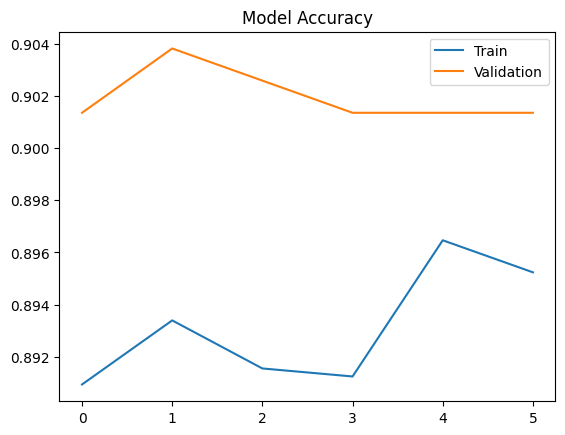

In [42]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Model Accuracy")
plt.legend(["Train","Validation"])
plt.show()

26/26 ━━━━━━━━━━━━━━━━━━━━ 50s 2s/step


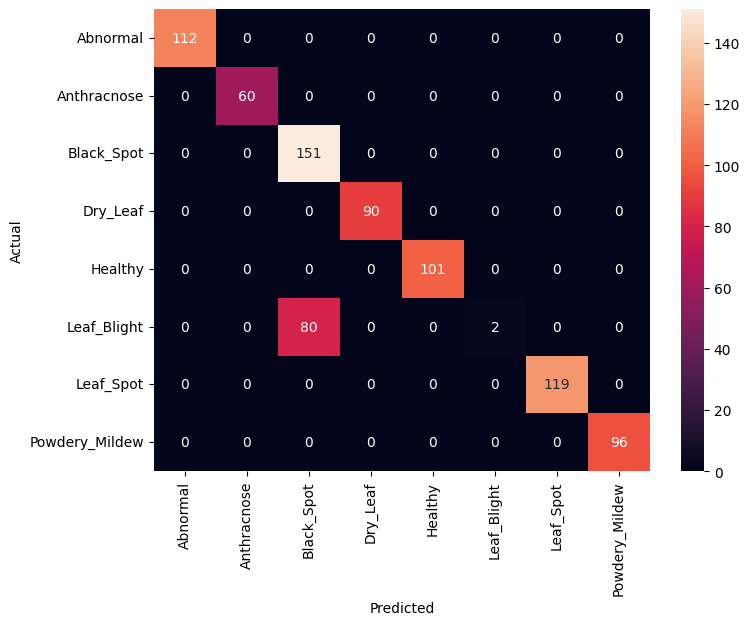

In [43]:
val_data.reset()

pred = model.predict(val_data)
pred_classes = np.argmax(pred, axis=1)

true_classes = val_data.classes
class_labels = list(val_data.class_indices.keys())

cm = confusion_matrix(true_classes, pred_classes)

plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=class_labels,
    yticklabels=class_labels
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [2]:
print(
    classification_report(
        true_classes,
        pred_classes,
        target_names=class_labels
    )
)

NameError: name 'classification_report' is not defined

In [1]:
import pandas as pd

# get report as dict so we can manipulate it
report_dict = classification_report(
    true_classes,
    pred_classes,
    target_names=class_labels,
    output_dict=True
)

df_report = pd.DataFrame(report_dict).transpose()

# select only the class rows (skip 'accuracy', 'macro avg', etc.)
scores = df_report.loc[class_labels, ['precision', 'recall', 'f1-score']]

# plot
scores.plot(kind='bar', figsize=(10, 6))
plt.title("Precision, Recall and F1‑score per Class")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.legend(loc="lower right")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

NameError: name 'classification_report' is not defined

In [46]:
import cv2

def predict_leaf(image_path):

    img = cv2.imread(image_path)
    img = cv2.resize(img,(224,224))

    img = preprocess_input(img)
    img = np.expand_dims(img,axis=0)

    prediction = model.predict(img)

    class_index = np.argmax(prediction)

    class_names = list(train_data.class_indices.keys())

    print("Prediction:",class_names[class_index])

In [47]:
print(classification_report(true_classes,
                            pred_classes,
                            target_names=class_labels))

                precision    recall  f1-score   support

      Abnormal       1.00      1.00      1.00       112
   Anthracnose       1.00      1.00      1.00        60
    Black_Spot       0.65      1.00      0.79       151
      Dry_Leaf       1.00      1.00      1.00        90
       Healthy       1.00      1.00      1.00       101
   Leaf_Blight       1.00      0.02      0.05        82
     Leaf_Spot       1.00      1.00      1.00       119
Powdery_Mildew       1.00      1.00      1.00        96

      accuracy                           0.90       811
     macro avg       0.96      0.88      0.85       811
  weighted avg       0.94      0.90      0.86       811



In [12]:
model.save("efficientnet_model.h5")